In [7]:
import os
from skimage.metrics import structural_similarity
from skimage.metrics import mean_squared_error
import math
import numpy as np
import sirf.Gadgetron as pMR
import matplotlib.pyplot as plt


data_path = '/home/jovyan/work/SIRF-Contribs/src/notebooks/'
os.chdir(data_path)
import utils
from utils import plot_rpe_3d, plot_rpe_3d_simple, plot_rpe_3d_simple_dir

# Can use either of these two as ground truth
# ground_truth_with_TV = np.load(os.path.join(data_path, 'ground_truth_with_TV.npy'))
# ground_truth_no_TV = np.load(os.path.join(data_path, 'ground_truth_no_TV.npy'))


Nms = 3

crop = 20


recons = {}
basedir = 'recons_ignore-acq_4bis2k'
# basedir = 'recons_ignore-acq_equal-tv'
for ms in ['no_motion', 'motion_no_mcir']:
    _fname = os.path.join(data_path, basedir, 'MS_3', f'im_fista_{ms}.h5' )
    recons[ms] =  pMR.ImageData(file=_fname).as_array()[crop:-crop,:,:] 

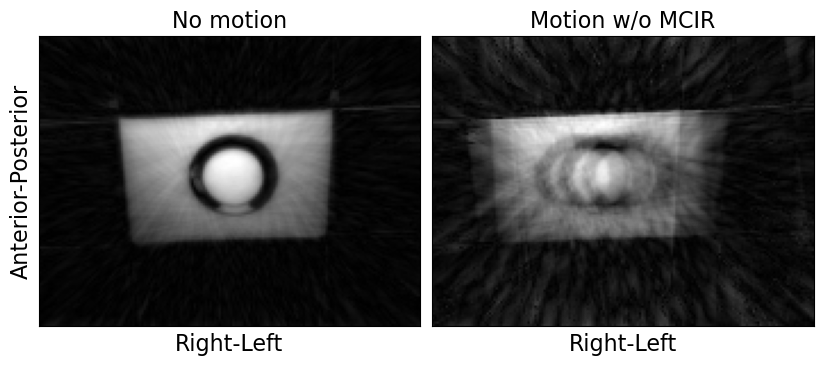

In [13]:
# increase the font size
# https://matplotlib.org/stable/users/explain/customizing.html
import matplotlib
# import matplotlib.pylab as pylab
params = {'axes.titlesize':'16', 'axes.labelsize':'16'}
# matplotlib.rcParams.update(matplotlib.rcParamsDefault)
# matplotlib.rcParams.update({'font.size': 14})
matplotlib.rcParams.update(params)

plot_rpe_3d_simple_dir([recons['no_motion'], recons['motion_no_mcir']], 
                   [64, 64],
                   ['No motion', 'Motion w/o MCIR'], hspace=0.2, wspace = 0.03, 
                      fig_name="compare-motion-nomotion-nomcir")
                       #, fig_name="motion_state_example")